# Examples for McKean-Vlasov control

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from main import McKeanVlasovSolver
from main import McKeanVlasovPlotter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from scipy.special import beta
from scipy.special import iv as bessel
from scipy.optimize import brentq
from scipy.linalg import eig
from tqdm import tqdm

## Initial distributions

In [3]:
def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x, a1=4.0, b1=2.0, a2=2.0, b2=10.0):
    alpha_param1, beta_param1 = a1, b1
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)
    alpha_param2, beta_param2 = a2, b2
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)

    result = 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1
    result += 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2
    
    return result

## Benedetto et al. (1998)

Consider $G(x) = \beta \frac{(x-\pi)^2}{2}$ and $W(x) = \lambda |x-\pi|^3$ over the interval $[0, 2\pi]$. 

The McKean-Vlasov equation with these functions is the homogeneous version of the transport equation in a thermal bath with temperature $\beta^{-1}$ that can be derived from inelastic collisions. 

In [4]:
G = lambda x: 5 * (x - np.pi)**2
W = lambda x: np.abs(x-np.pi)**3

alpha1 = lambda x: np.sin(x) / np.sqrt(4 * np.pi) 
alpha2 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
alpha3 = lambda x: np.sin(2*x) / np.sqrt(4 * np.pi) 
alpha4 = lambda x: np.cos(2*x) / np.sqrt(4 * np.pi) 

nabla_alpha1 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
nabla_alpha2 = lambda x: -np.sin(x) / np.sqrt(4 * np.pi) 
nabla_alpha3 = lambda x: 2 * np.cos(2*x) / np.sqrt(4 * np.pi) 
nabla_alpha4 = lambda x: -2 * np.sin(2*x) / np.sqrt(4 * np.pi) 

Solving the equation. 

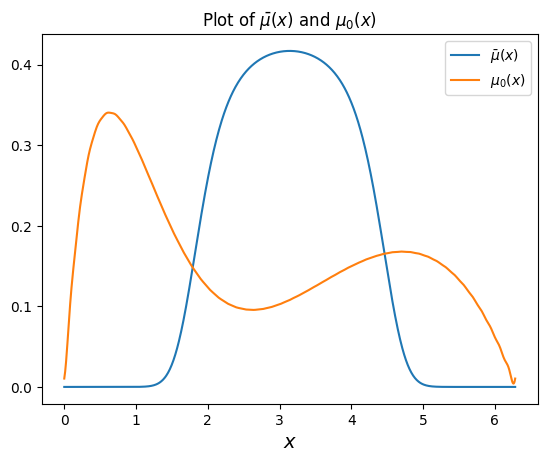

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.27.
MESSAGE - Nonlinear equation solved in 5.86.


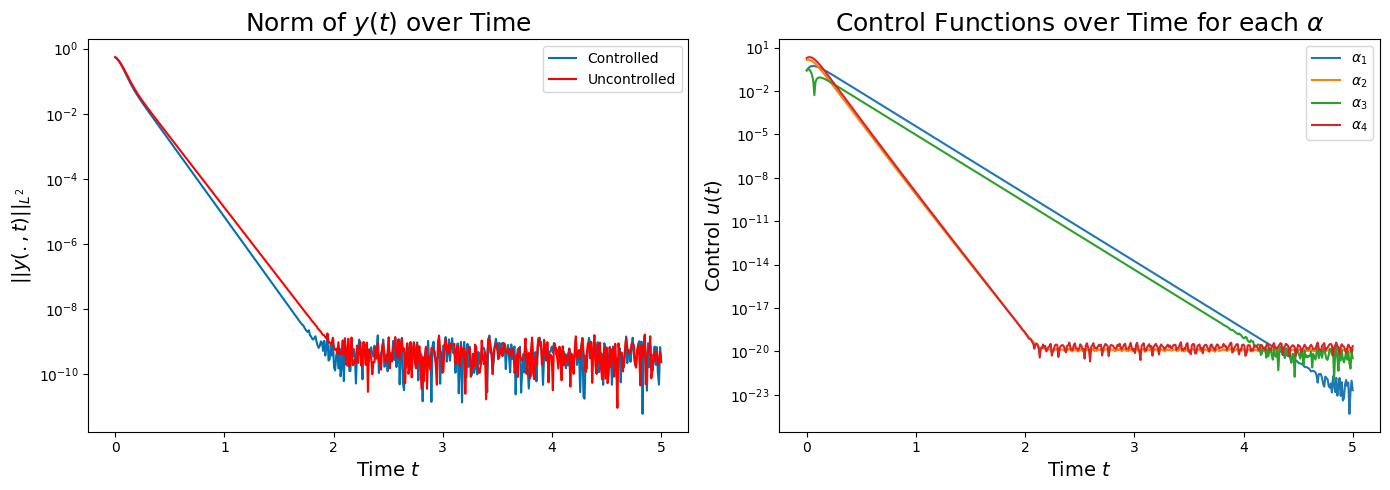

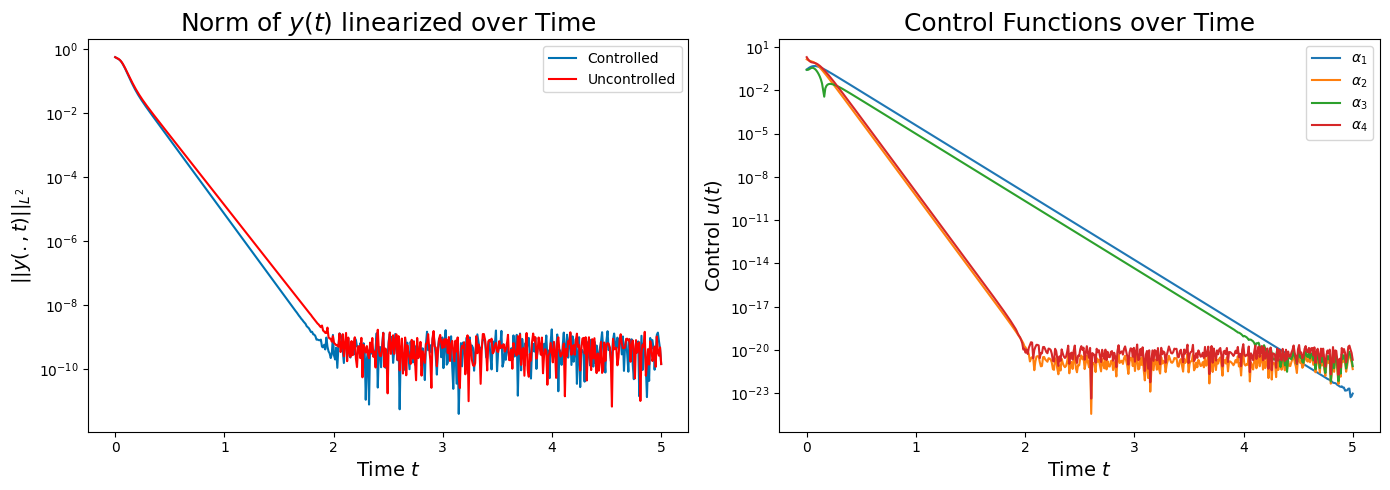

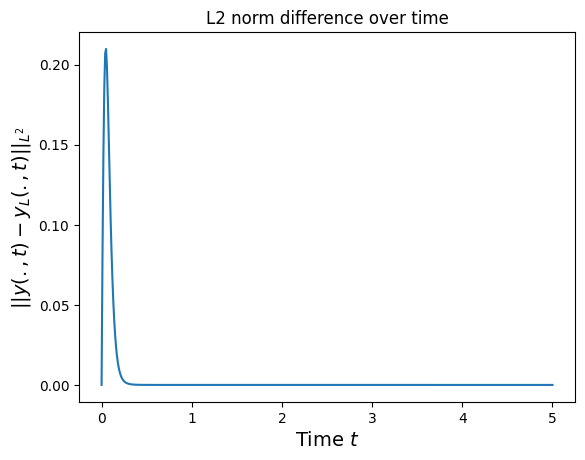

In [5]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=5.0)
plotter.plot_control_and_norm_linear(t_max=5.0)
plotter.plot_y_diff_L2_norm(t_max=5.0)

Consider now a smaller value of $\beta$ (so a higher temperature). 

In [6]:
G = lambda x: 1e-8 * (x - np.pi)**2

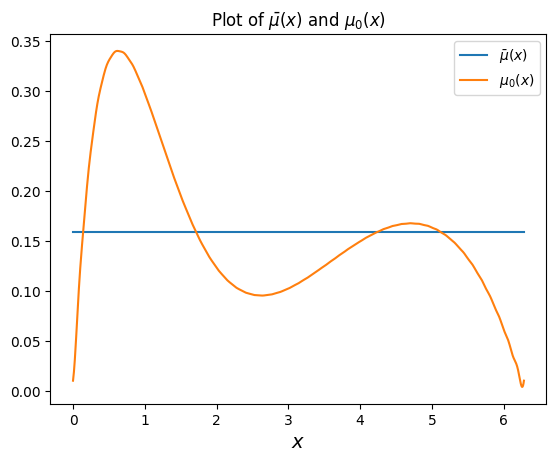

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.12.
MESSAGE - Nonlinear equation solved in 6.16.


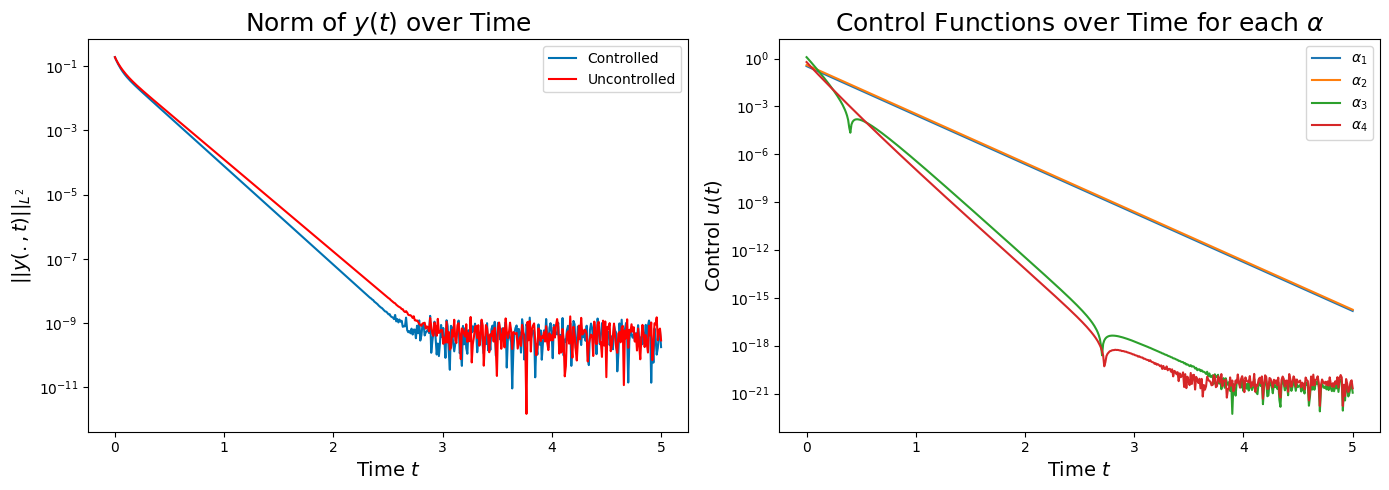

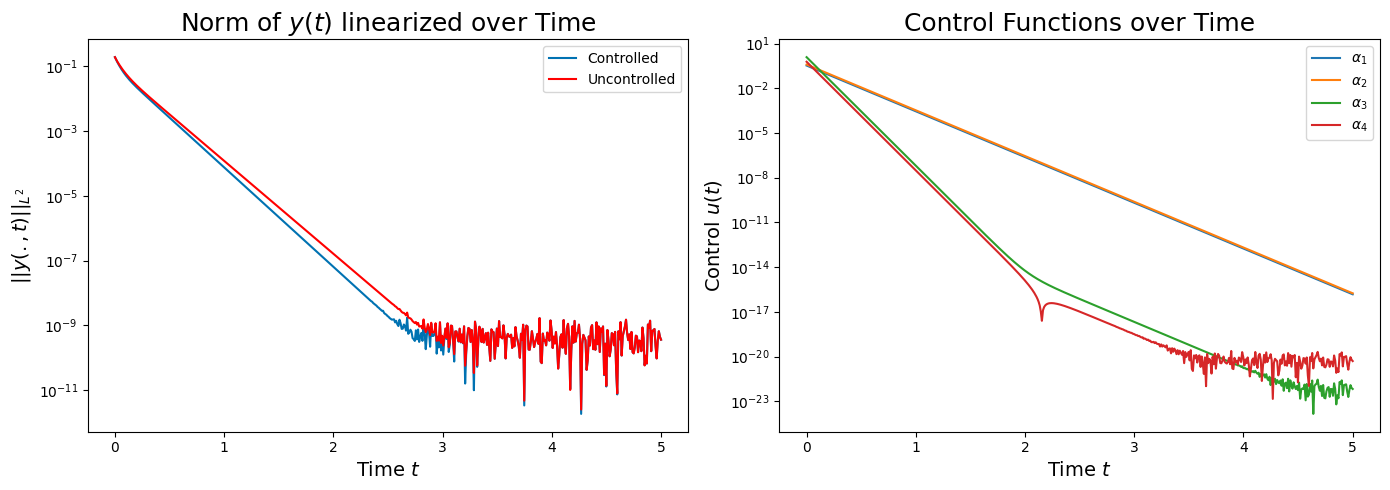

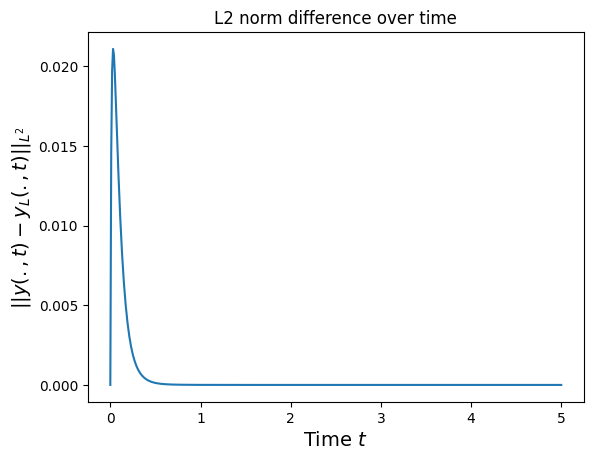

In [7]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=5.0)
plotter.plot_control_and_norm_linear(t_max=5.0)
plotter.plot_y_diff_L2_norm(t_max=5.0)

## Kuramoto model

Consider $G(x) = 0$ and $W(x) = -K \cos(x)$. First, $K = 1$. 

In [4]:
K = 1
G = lambda x: np.zeros_like(x)
W = lambda x: -K*np.cos(x)

In [5]:
def spectral_gap_bound(K):
    """
    Calculate the spectral gap lower bound given by equation (1.25) of 
    Bertini, Giacomin, and Pakdaman (2009).
    """
    if K <= 1:
        return 0.0
    r = unique_r(K)
    I_0 = bessel(0, 2*K*r)
    I_0_squared = I_0**2
    
    exp_4Kr = np.exp(4 * K * r)
    exp_8Kr = exp_4Kr**2
    
    scaled_numerator = (1 - K * (1 - r*r)) / exp_4Kr
    scaled_denominator = 2 * K * r*r / (1 - 1/I_0_squared) * exp_4Kr + 1
    
    return scaled_numerator / scaled_denominator

def unique_r(K):
    """
    Calculate the first cosine Fourier coefficient of q_hat.
    """
    if K <= 1:
        return 0.0
    psi = lambda x: bessel(1, x) / bessel(0, x)
    func = lambda r: r - psi(2 * K * r)
    # We know that when K > 1, r(K) in (sqrt(1 - 1/K), sqrt(1 - 1/2K)), see equation (2.4).
    r = brentq(func, a=np.sqrt(1 - 1/K), b=np.sqrt(1 - 1/(2*K)))
    return r

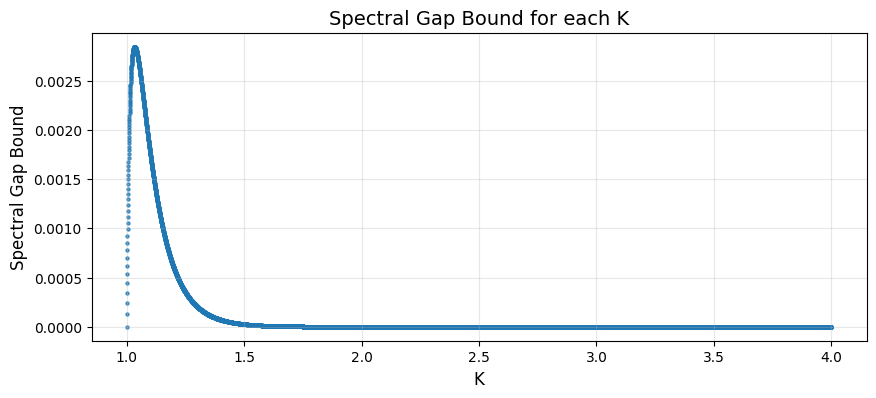

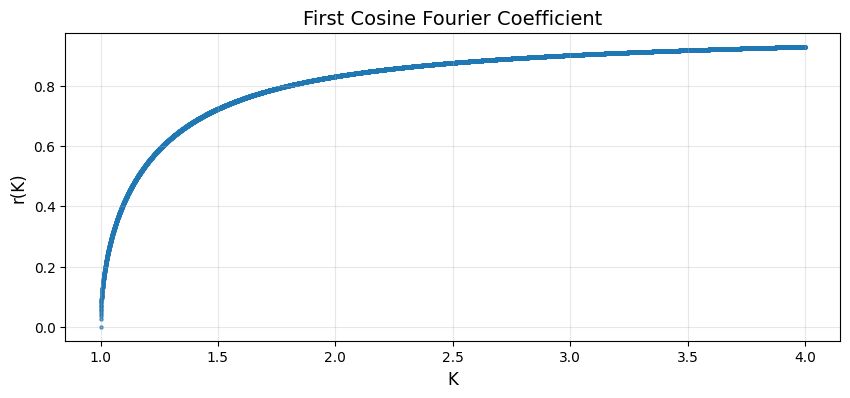

In [6]:
K_values = np.linspace(1, 4, 10000)
spectral_values = [spectral_gap_bound(K) for K in K_values]
r_values = [unique_r(K) for K in K_values]

# Plotting
plt.figure(figsize=(10, 4))
plt.scatter(K_values, spectral_values, s=5, alpha=0.7)
plt.title('Spectral Gap Bound for each K', fontsize=14)
plt.xlabel('K', fontsize=12)
plt.ylabel('Spectral Gap Bound', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.scatter(K_values, r_values, s=5, alpha=0.7)
plt.title('First Cosine Fourier Coefficient', fontsize=14)
plt.xlabel('K', fontsize=12)
plt.ylabel('r(K)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
spectral_gap_values = []

for K in tqdm(np.linspace(1.1, 4, 20)):

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=lambda x: np.zeros_like(x), alpha=[None], 
                                W=lambda x: -K*np.cos(x), mu_0=mu_0, min_fourier_samples=2000, delta=-0.0001, 
                                grad_alpha="constant", 
                                state_weight=1000, sigma=0.5)
    
    t_max = 100
    while True:
        a_bar = solver.nonlinear_controlled_solver_mu(t_span=(0, t_max), t_eval=(t_max/2, t_max), u=lambda t,a: np.zeros(4))
        if np.linalg.norm(a_bar.y[:,-1] - a_bar.y[:,-2]) < 1e-8:
            break
        else:
            t_max *= 5
            print("t_max = {}, norm = {}".format(t_max, np.linalg.norm(a_bar.y[:,-1] - a_bar.y[:,-2])))
    
    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=lambda x: np.zeros_like(x), alpha=[None], 
                                W=lambda x: -K*np.cos(x), mu_0=mu_0, min_fourier_samples=2000, delta=-0.0001, 
                                grad_alpha="constant", 
                                state_weight=1000, sigma=0.5, final_distribution=a_bar.y[:,-1])
    
    linear_operator = -(solver.L_G + solver.K + solver.sigma * solver.D)
    eigenvalues, _ = eig(linear_operator)
    sorted_indices = np.argsort(eigenvalues.real)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]

    spectral_gap_values.append(abs(sorted_eigenvalues[1].real))

  0%|                                                    | 0/20 [00:00<?, ?it/s]

t_max = 500, norm = 0.0005724894716616121


  5%|██▏                                         | 1/20 [00:10<03:15, 10.31s/it]

t_max = 500, norm = 1.059165611145379e-06


100%|███████████████████████████████████████████| 20/20 [00:52<00:00,  2.65s/it]


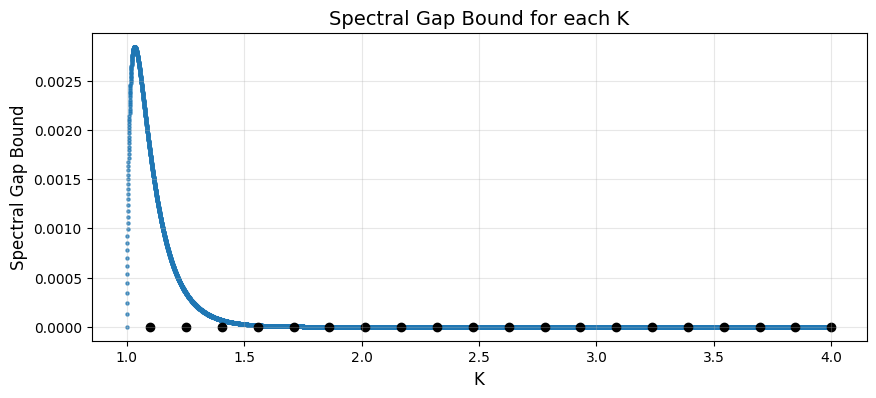

In [12]:
plt.figure(figsize=(10, 4))
plt.scatter(K_values, spectral_values, s=5, alpha=0.7)
plt.scatter(np.linspace(1.1, 4, 20), spectral_gap_values, color="black")
plt.title('Spectral Gap Bound for each K', fontsize=14)
plt.xlabel('K', fontsize=12)
plt.ylabel('Spectral Gap Bound', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

First let us check for $K > 1$ if the true distribution is being achieved as expected.

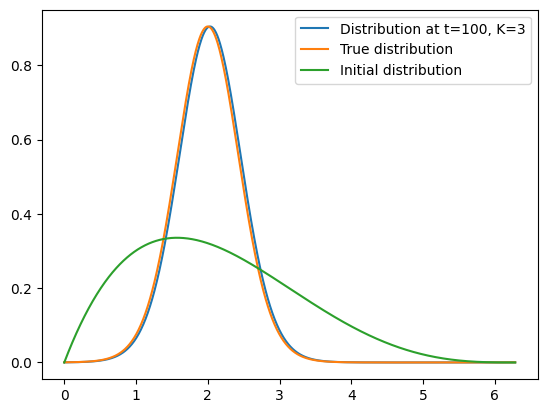

In [72]:
K = 3
G = lambda x: np.zeros_like(x)
W = lambda x: -K*np.cos(x)

x = np.linspace(0, 2*np.pi, 1000)

initial_dist = lambda x: mu_0_mixed(x, a1=2.0, b1=4.0, a2=2.0, b2=4.0)

solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=initial_dist, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

a_bar = solver.nonlinear_controlled_solver_mu(t_span=(0, 5), t_eval=(5,), u=lambda t,a: np.zeros(4))
mu_bar = solver.reconstruction(a_bar.y[:,-1], x)

plt.plot(x, mu_bar, label="Distribution at t=100, K={}".format(K))
plt.plot(x, np.exp(2*K*unique_r(K)*np.cos(x-2)) / np.trapezoid(np.exp(2*K*unique_r(K)*np.cos(x-2)), x), label="True distribution")
plt.plot(x, initial_dist(x), label="Initial distribution")
plt.legend()
plt.show()

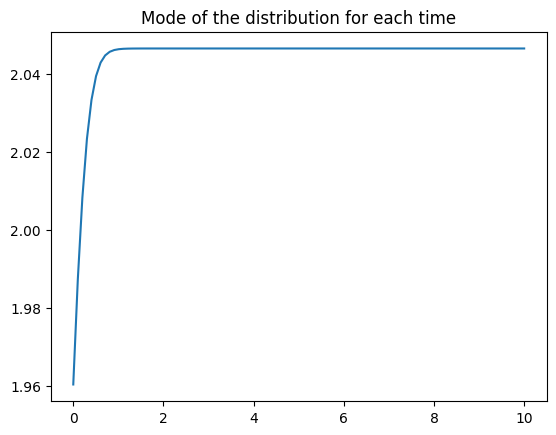

In [41]:
K = 5
G = lambda x: np.zeros_like(x)
W = lambda x: -K*np.cos(x)

x = np.linspace(0, 2*np.pi, 1000)

initial_dist = lambda x: mu_0_mixed(x, a1=2.0, b1=4.0, a2=2.0, b2=4.0)
solver = McKeanVlasovSolver(L=10, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=initial_dist, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

a_bar = solver.nonlinear_controlled_solver_mu(t_span=(0, 10), t_eval=np.linspace(0, 10, 100), u=lambda t,a: np.zeros(4))

sin_avg_time = np.array([np.trapezoid(np.sin(x) * solver.reconstruction(a_bar.y[:,i], x), x) for i in range(100)])
cos_avg_time = np.array([np.trapezoid(np.cos(x) * solver.reconstruction(a_bar.y[:,i], x), x) for i in range(100)])
theta_values = np.atan2(sin_avg_time, cos_avg_time)

plt.plot(a_bar.t, theta_values)
plt.title("Mode of the distribution for each time")
plt.show()

In [19]:
G = lambda x: np.zeros_like(x)
W = lambda x: -0.95*np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

I am using $\sigma = 0.5$ to follow the reference.

In [31]:
solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

plotter = McKeanVlasovPlotter(solver)

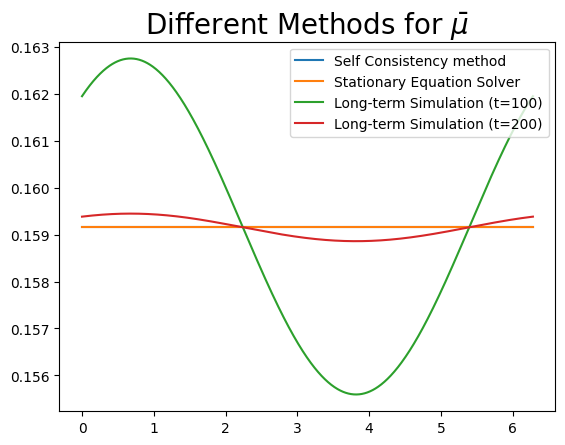

In [32]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 200), t_eval=(100, 200,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=100)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=200)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

For this example, we expect the density to converge to the uniform distribution. By using control on the linearsed equation, we can accelerate this convergence. Here, for example, in 2 seconds, we achieve the L2 norm of $10^{-9}$, while without control we would get something higher than $10^{-3}$. 

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.02.
MESSAGE - Nonlinear equation solved in 0.24.


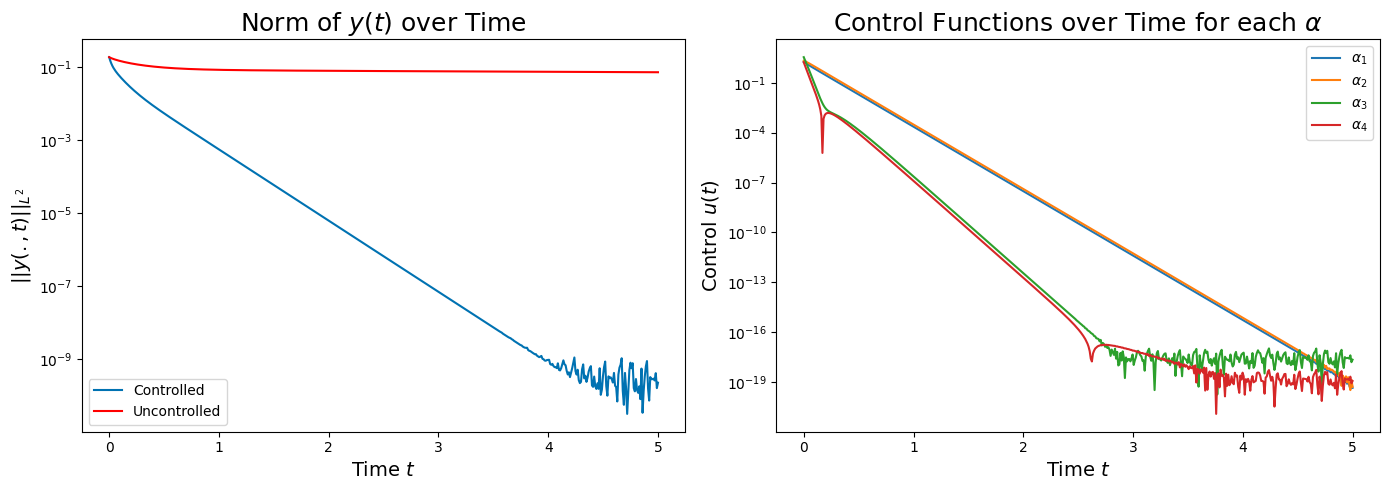

In [34]:
plotter.plot_control_and_norm(t_max=5.0)

For $K=5$, the situation is different. There is the presence of a second stationary distribution and the uniform one turns out to be unstable. Let's see what is means to linearise around the **unstable** steady state. 

In [35]:
G = lambda x: np.zeros_like(x)
W = lambda x: -5*np.cos(x)

solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

plotter = McKeanVlasovPlotter(solver)

Notice that the methods disagree on the solution, which was something possible as discussed. For this case, the convergence to the **stable** steady state is very fast.

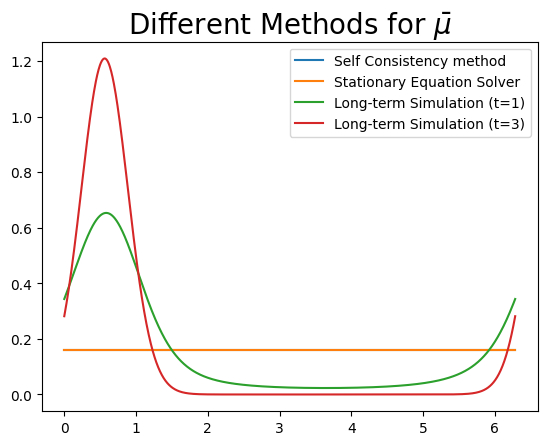

In [16]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 3), t_eval=(1, 3,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=1)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=3)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

Controlling the equation leads to a situation where we are able to bring the solution close to the unstable steady state.

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.02.
MESSAGE - Nonlinear equation solved in 0.23.


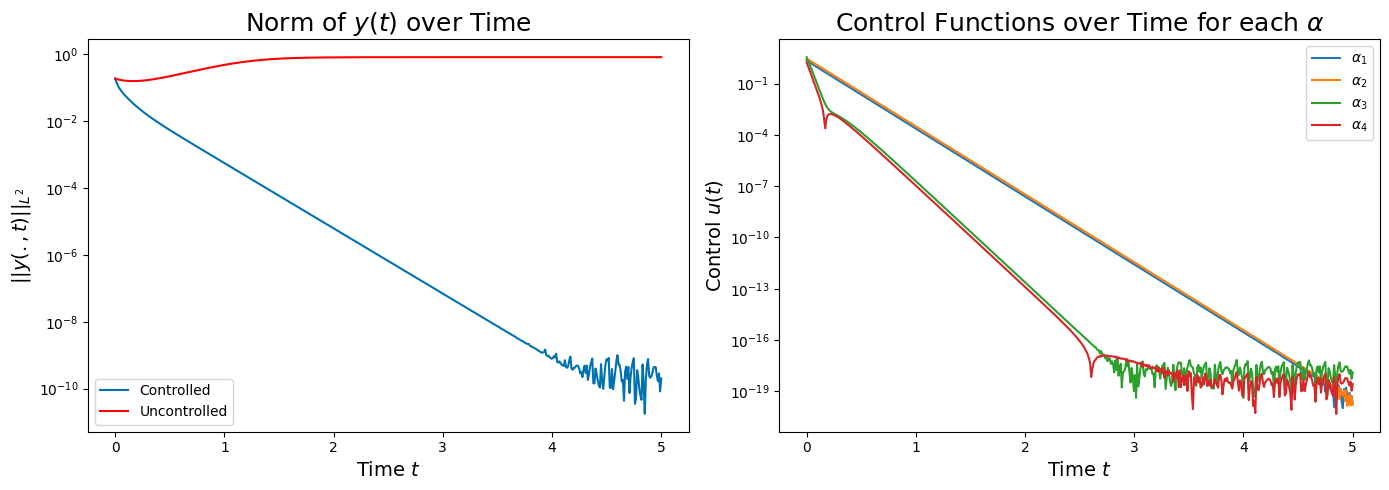

In [17]:
plotter.plot_control_and_norm(t_max=5.0)

### Interesting aspect

We know that for a given initial distribution, if $K > 1$, we are going to converge to a distribution which is proportional to a translation of $\exp(2Kr\cos(x))$. The question is: can we force to other stationary distribution? 

In [37]:
K = 2
r = unique_r(K)
x = np.linspace(0, 2*np.pi, 1000)
Z = np.trapezoid(np.exp(2*K*r*np.cos(x)), x)
desired_distribution = lambda x, alpha=0.0: np.exp(2*K*r*np.cos(x-alpha)) / Z
a = solver._project_Fourier_basis_FFT(func=desired_distribution)

In [33]:
G = lambda x: np.zeros_like(x)
W = lambda x: -K*np.cos(x)

initial_distribution = lambda x: mu_0_mixed(x, a1=2.0, b1=2.0, a2=2.0, b2=2.0)

solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=initial_distribution, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, final_distribution=a)

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.02.
MESSAGE - Nonlinear equation solved in 0.61.


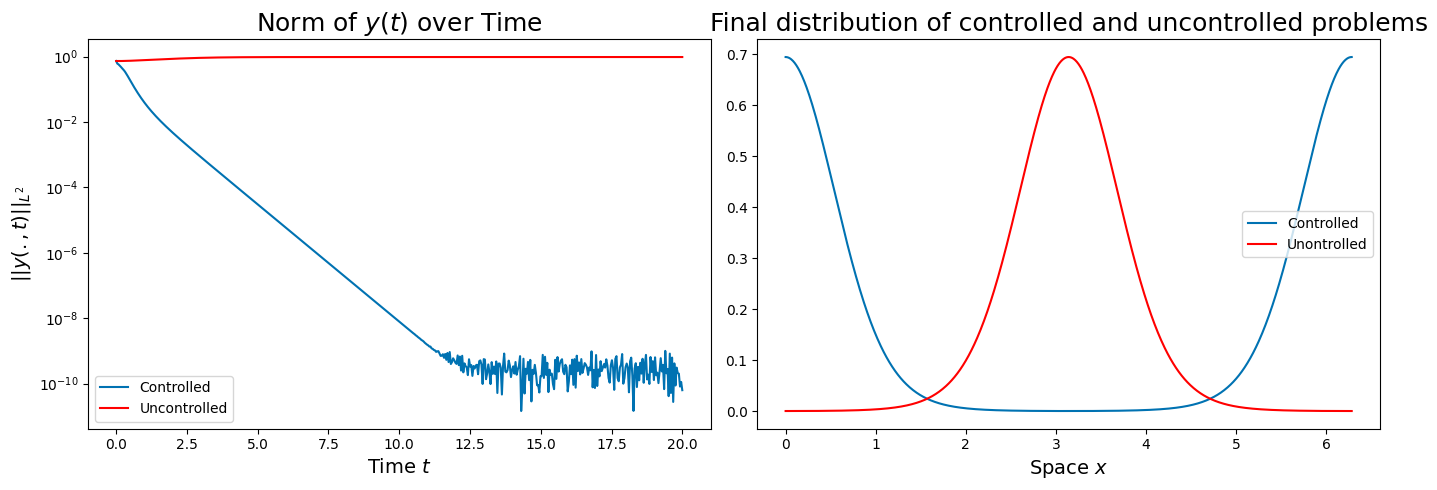

In [34]:
solution = solver.solve_control_problem(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))
solution_uncontrolled = solver.nonlinear_uncontrolled_solver_y(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))

t_points = solution.t
control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

y_norm = np.linalg.norm(solution.y, axis=0)
y_norm2 = np.linalg.norm(solution_uncontrolled.y, axis=0)

# Creating the subplot figure
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plotting ||y(., t)||_{L^2} over time
ax1.plot(t_points, y_norm, color="#0072B2", label="Controlled")
ax1.plot(t_points, y_norm2, color="red", label="Uncontrolled")
ax1.set_xlabel('Time $t$', fontsize=14)
ax1.set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax1.set_title('Norm of $y(t)$ over Time', fontsize=18)
ax1.set_yscale("log")
ax1.legend()

ax2.plot(x, solver.reconstruction(solution.y[:,-1] + a, x), label="Controlled", color="#0072B2")
ax2.plot(x, solver.reconstruction(solution_uncontrolled.y[:,-1] + a, x), label="Unontrolled", color="red")
ax2.set_xlabel('Space $x$', fontsize=14)
ax2.set_title('Final distribution of controlled and uncontrolled problems', fontsize=18)
ax2.legend()

plt.tight_layout()
plt.show()

### Changing the values of K

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 0.62.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 0.61.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 0.59.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 0.60.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 0.60.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 0.62

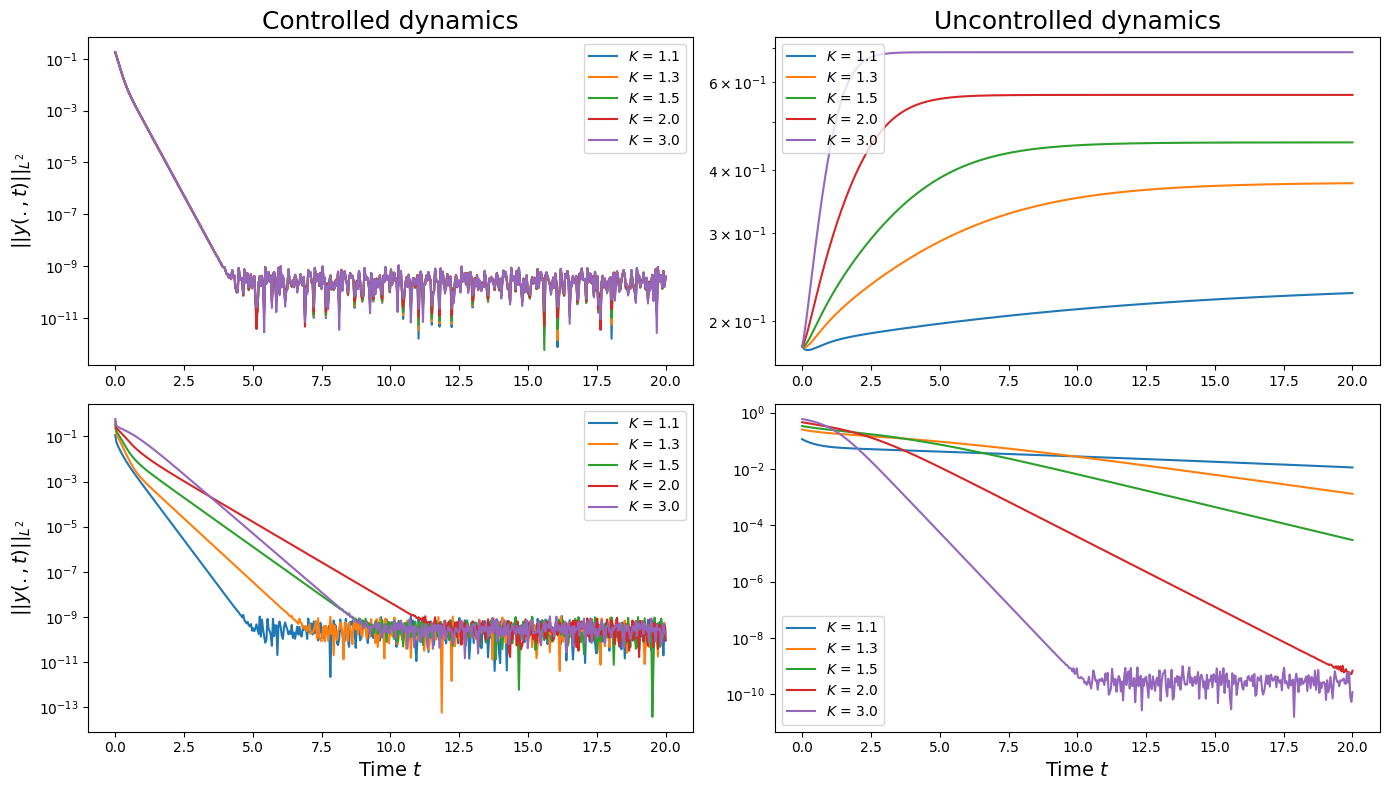

In [43]:
_, ax = plt.subplots(2, 2, figsize=(14, 8))

K_values = [1.1, 1.3, 1.5, 2.0, 3.0]

for index, K in enumerate(K_values):

    # Control to the uniform distribution
    solver1 = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=lambda x: -K*np.cos(x), mu_0=initial_distribution, min_fourier_samples=2000, delta=-0.0001, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=1000, sigma=0.5)

    # Control to the stable distribution
    r = unique_r(K)
    Z = np.trapezoid(np.exp(2*K*r*np.cos(x)), x)
    desired_distribution = lambda x: np.exp(2*K*r*np.cos(x-np.pi)) / Z
    a = solver._project_Fourier_basis_FFT(func=desired_distribution)
    
    solver2 = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=lambda x: -K*np.cos(x), mu_0=initial_distribution, min_fourier_samples=2000, delta=-0.0001, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=1000, sigma=0.5, 
                                final_distribution=a)

    solution1 = solver1.solve_control_problem(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))
    solution_uncontrolled1 = solver1.nonlinear_uncontrolled_solver_y(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))

    solution2 = solver2.solve_control_problem(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))
    solution_uncontrolled2 = solver2.nonlinear_uncontrolled_solver_y(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))

    y_norm1 = np.linalg.norm(solution1.y, axis=0)
    y_norm_uncontrolled1 = np.linalg.norm(solution_uncontrolled1.y, axis=0)

    y_norm2 = np.linalg.norm(solution2.y, axis=0)
    y_norm_uncontrolled2 = np.linalg.norm(solution_uncontrolled2.y, axis=0)

    ax[0,0].plot(t_points, y_norm1, label=r"$K$ = {}".format(K))
    ax[0,1].plot(t_points, y_norm_uncontrolled1, label=r"$K$ = {}".format(K))
    ax[1,0].plot(t_points, y_norm2, label=r"$K$ = {}".format(K))
    ax[1,1].plot(t_points, y_norm_uncontrolled2, label=r"$K$ = {}".format(K))
    
ax[1,0].set_xlabel('Time $t$', fontsize=14)
ax[1,1].set_xlabel('Time $t$', fontsize=14)
ax[0,0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[1,0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0,0].set_title('Controlled dynamics', fontsize=18)
ax[0,1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0,0].set_yscale("log")
ax[0,1].set_yscale("log")
ax[1,0].set_yscale("log")
ax[1,1].set_yscale("log")
ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

## Kuramoto model + confining potential G

Let us change the model a little bit to include a non-zero potential $G$. 

$$
G(x) = cos(2x), W(x) = -cos(x)
$$

For $\sigma \ge 0.78$, we expect the single solution to be $\rho(x) = \exp(-cos(2x)/\sigma)$. For $\sigma < 0.77$, we have this solution plus other two with pick being at $\pi/2$ and $3\pi/2$.

Consider the example given in https://arxiv.org/pdf/2211.08004#page=7.23

In [16]:
G = lambda x: np.cos(2 * x)
W = lambda x: -np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

Consider $\sigma = 0.78$. We expect a slow convergence.

In [18]:
sigma = 0.78

solver = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 1000), t_eval=(500, 1000,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

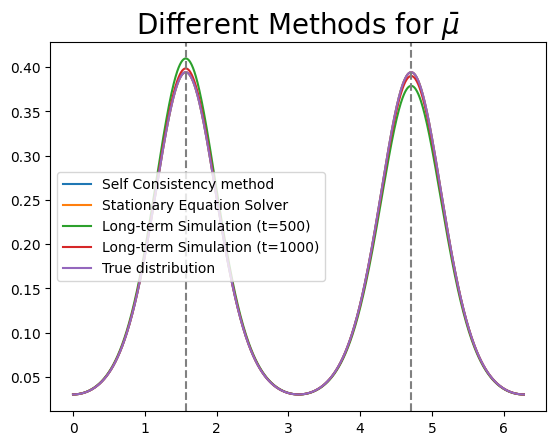

In [19]:
plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=500)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=1000)")
plt.plot(x, np.exp(-np.cos(2*x)/sigma) / np.trapezoid(np.exp(-np.cos(2*x)/sigma), x), label="True distribution")
plt.axvline(2*np.pi-np.pi/2, ls="--", c="gray")
plt.axvline(np.pi/2, ls="--", c="gray")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

For $\sigma < 0.77$, we know there will be other two stationary distributions

In [20]:
sigma = 0.6

solver = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 1000), t_eval=(500, 1000,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

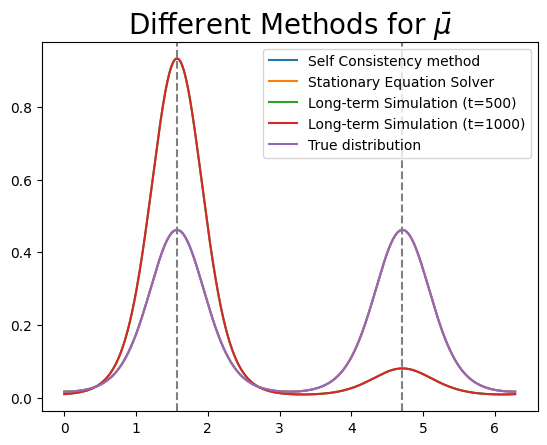

In [21]:
plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=500)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=1000)")
plt.plot(x, np.exp(-np.cos(2*x)/sigma) / np.trapezoid(np.exp(-np.cos(2*x)/sigma), x), label="True distribution")
plt.axvline(2*np.pi-np.pi/2, ls="--", c="gray")
plt.axvline(np.pi/2, ls="--", c="gray")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

## O(2) model with magnetic field

Now we consider a different model over $[0,1]$:

$G(x) = -\eta cos(2\pi x), W(x) = -cos(2\pi x)$.  

In [22]:
eta = 0.05
G = lambda x: -eta * np.cos(2 * np.pi * x)
W = lambda x: -np.cos(2 * np.pi * x)
sigma = 0.4678 # close to threshold
d = 1
    
solver = McKeanVlasovSolver(L=20, d=d, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

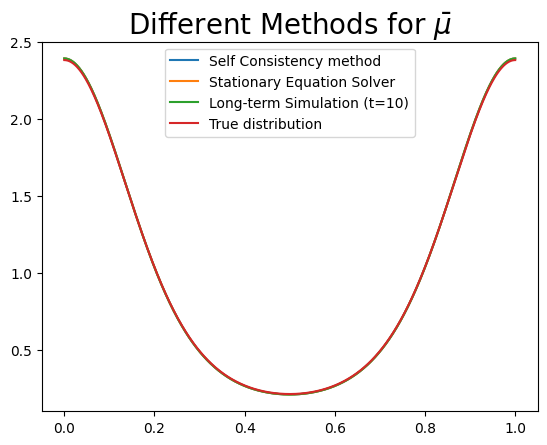

In [23]:
x = np.linspace(0, d, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation", bar_mu_k_initial=solver.bar_mu_k[solver.L+1:])
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 10), t_eval=(10,), u=lambda t,a: np.zeros(4))
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=10)")
a = 1.2
plt.plot(x, np.exp(a*np.cos(2*np.pi*x)) / np.trapezoid(np.exp(a*np.cos(2*np.pi*x)), x), label="True distribution")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

A small modification over $[0,2\pi]$:

$G(x) = -\eta cos(x), W(x) = -cos(x)$.  

In [24]:
eta = 0.05
G = lambda x: -eta * np.cos(x)
W = lambda x: -np.cos(x)
sigma = 0.4678
d = 2*np.pi
    
solver = McKeanVlasovSolver(L=20, d=d, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

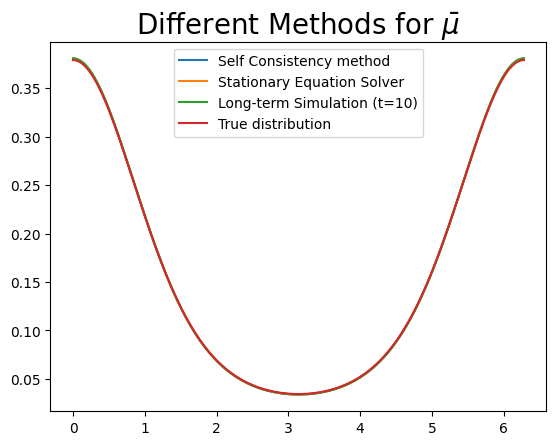

In [25]:
x = np.linspace(0, d, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation", bar_mu_k_initial=solver.bar_mu_k[solver.L+1:])
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 100), t_eval=(100,), u=lambda t,a: np.zeros(4))
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=10)")
a = 1.2
plt.plot(x, np.exp(a*np.cos(x)) / np.trapezoid(np.exp(a*np.cos(x)), x), label="True distribution")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

Another modification: 
$G(x) = -\eta cos(2x), W(x) = -Kcos(x)$.  

In this case, every stationary state has the form 

$$
\rho_{\infty}(x) \propto \exp\left(-\frac{1}{\sigma}(K r_1 \cos(x) + \eta \cos(2x))\right)
$$

### -> There is a point of problem here to analyse better. The negative sign poses a problem

In [26]:
eta = 0.5
K = 1.62
G = lambda x: -eta * np.cos(2*x)
W = lambda x: -K * np.cos(x)

solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

plotter = McKeanVlasovPlotter(solver)

In [27]:
def simulate_mckean_vlasov_torus(eta, K, N=2000, T=20.0, dt=0.01, sigma=1.0, seed=42):
    np.random.seed(seed)
    num_steps = int(T / dt)

    # Initialize particles on [0, 2π)
    X = np.random.uniform(0, 2 * np.pi, N)

    sqrt_2sigma_dt = np.sqrt(2 * sigma * dt)

    for step in tqdm(range(num_steps), desc="Simulating"):
        # Compute gradients
        gradV = 2 * eta * np.sin(2 * X)
        delta = (X[:, None] - X[None, :]+np.pi) % (2 * np.pi) - np.pi
        gradW = K * np.sin(delta)
        sum_gradW = gradW.mean(axis=1)

        # Euler-Maruyama update
        X += (-gradV - sum_gradW) * dt + sqrt_2sigma_dt * np.random.randn(N)
        X %= 2 * np.pi  # Periodic boundary

    return X

final_samples = simulate_mckean_vlasov_torus(eta=eta, K=K)

Simulating: 100%|███████████████████████████| 2000/2000 [01:28<00:00, 22.71it/s]


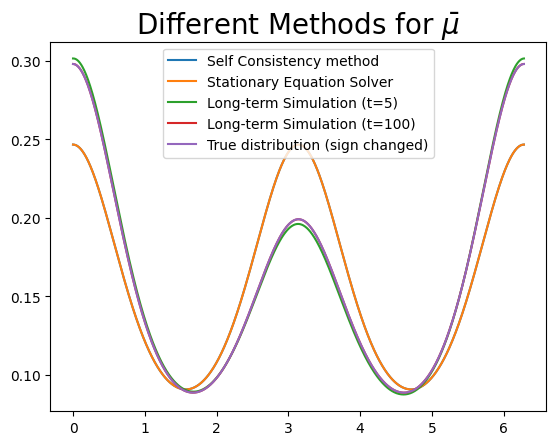

In [28]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 100), t_eval=(5, 100,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

r1 = np.trapezoid(np.cos(x)*mu_bar3_2, x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=5)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=100)")
plt.plot(x, np.exp(K*r1*np.cos(x) + eta*np.cos(2*x)) / np.trapezoid(np.exp(K*r1*np.cos(x) + eta*np.cos(2*x)), x),
         label="True distribution (sign changed)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

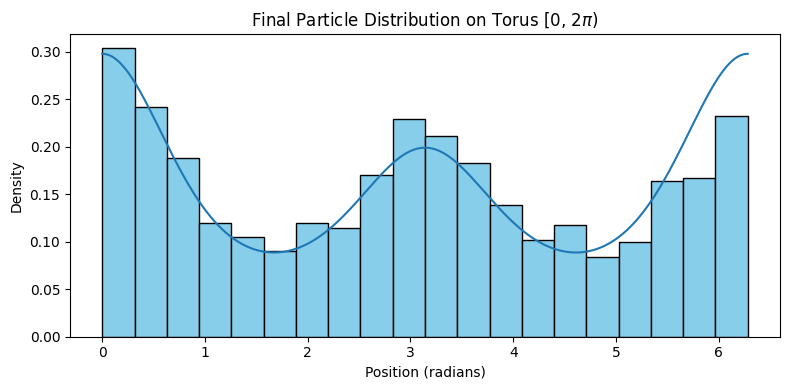

In [29]:
plt.figure(figsize=(8, 4))
plt.hist(final_samples, bins=20, density=True, color='skyblue', edgecolor='black')
plt.plot(x, mu_bar3_2)
plt.title("Final Particle Distribution on Torus [0, $2\pi$)")
plt.xlabel("Position (radians)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [30]:
eta = 0.5
G = lambda x: -eta * np.cos(2*x)
W = lambda x: -1.6*np.cos(x)

solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

plotter = McKeanVlasovPlotter(solver)

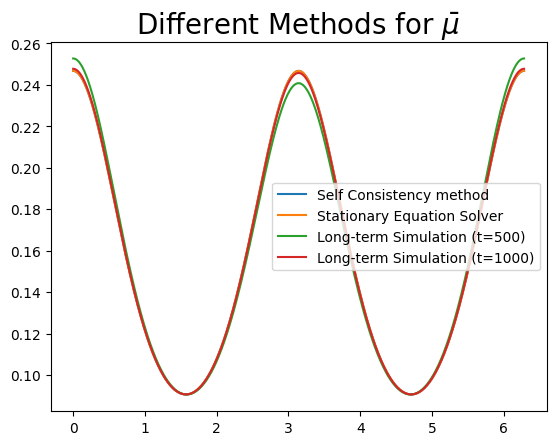

In [31]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 1000), t_eval=(500, 1000,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=500)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=1000)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

## Adding the controller

In [88]:
G = lambda x: np.cos(2 * x)
W = lambda x: -np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

sigma_values = [0.77, 0.79, 0.81, 0.83, 0.85]

t_max = 50

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 4.20.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 4.00.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 3.84.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 3.71.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 3.67.


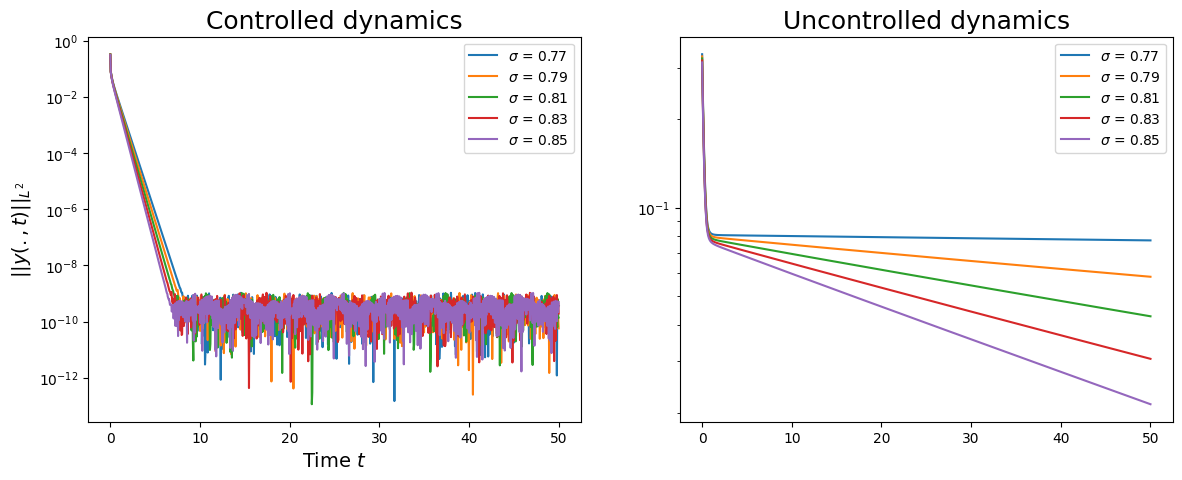

In [89]:
_, ax = plt.subplots(1, 2, figsize=(14, 5))

for i, sigma in enumerate(sigma_values):

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000)


    solution = solver.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))
    solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))

    # Calculate the L^2 norm of y(t)
    y_norm = np.linalg.norm(solution.y, axis=0)
    y_norm2 = np.linalg.norm(solution2.y, axis=0)

    t_points = solution.t
    control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

    ax[0].plot(t_points, y_norm, label=r"$\sigma$ = {}".format(sigma))
    ax[1].plot(t_points, y_norm2, label=r"$\sigma$ = {}".format(sigma))
    
ax[0].set_xlabel('Time $t$', fontsize=14)
ax[0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].legend()
ax[1].legend()

plt.show()

We covered the accelerate to the steady state part. Now we are also interested when the distribution is converging to other distribution.

As we discussed, when $\sigma < 0.77$ (even for $\sigma = 0.769$ we are apparently converging to other distribution), we have the case where $\rho(x) = \exp(-cos(2x)/\sigma)$ is a solution but we got other stationary distribution.

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 5.58.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 4.83.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 4.10.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 3.93.


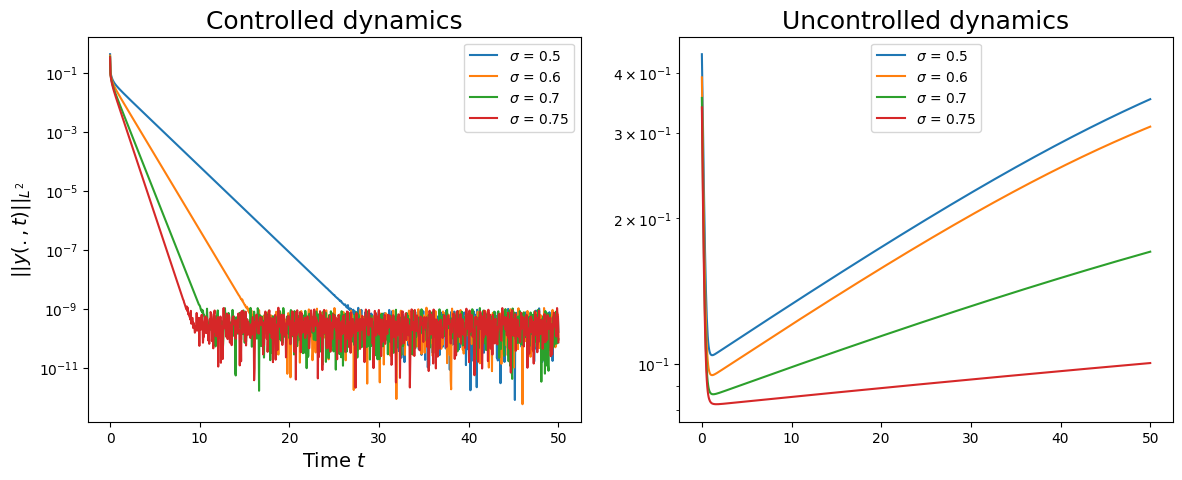

In [90]:
_, ax = plt.subplots(1, 2, figsize=(14, 5))

sigma_values = [0.5, 0.6, 0.7, 0.75]

for i, sigma in enumerate(sigma_values):

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000)

    C = solver._integrate(f=lambda x: np.exp(-np.cos(2*x)/sigma), n_points=2000)
    final_distribution = solver._project_Fourier_basis_FFT(func=lambda x: np.exp(-np.cos(2*x)/sigma) / C)

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000, final_distribution=final_distribution)

    solution = solver.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))
    solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))

    # Calculate the L^2 norm of y(t)
    y_norm = np.linalg.norm(solution.y, axis=0)
    y_norm2 = np.linalg.norm(solution2.y, axis=0)

    t_points = solution.t
    control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

    ax[0].plot(t_points, y_norm, label=r"$\sigma$ = {}".format(sigma))
    ax[1].plot(t_points, y_norm2, label=r"$\sigma$ = {}".format(sigma))
    
ax[0].set_xlabel('Time $t$', fontsize=14)
ax[0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].legend()
ax[1].legend()

plt.show()

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 9.20.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 7.11.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 5.58.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.01.
MESSAGE - Nonlinear equation solved in 4.40.


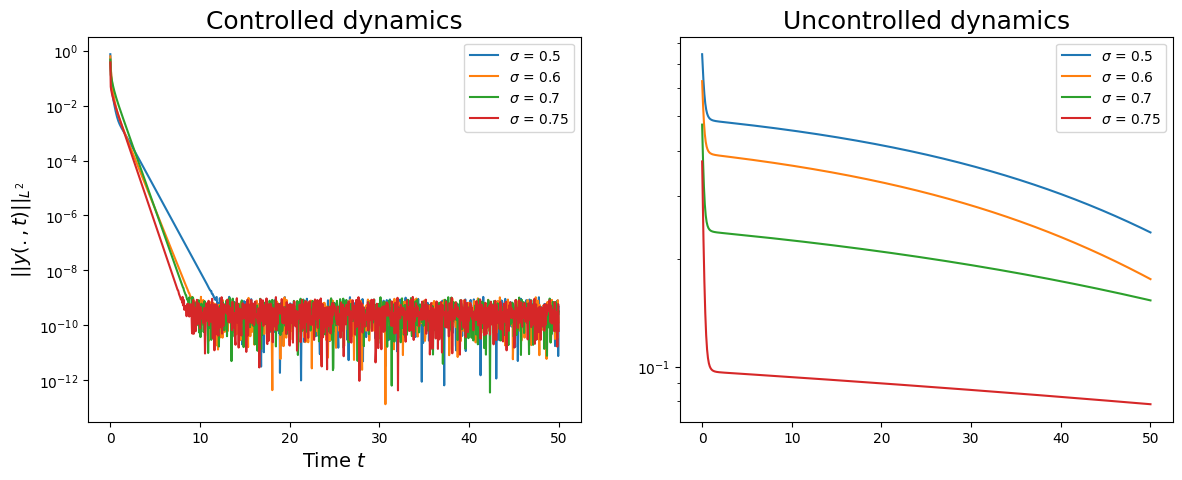

In [91]:
_, ax = plt.subplots(1, 2, figsize=(14, 5))

sigma_values = [0.5, 0.6, 0.7, 0.75]
t_max = 50

for i, sigma in enumerate(sigma_values):

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000)
    
    final_time = 1000
    while True:
        mu = solver.nonlinear_uncontrolled_solver_mu(t_span=(0, final_time), t_eval=(final_time/2, final_time))
        if np.linalg.norm(mu.y[:,-2] - mu.y[:,-1]) < 1e-6:
            break
        else:
            final_time *= 2

    final_distribution = mu.y[:,-1]
    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000, final_distribution=final_distribution)

    solution = solver.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))
    solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))

    # Calculate the L^2 norm of y(t)
    y_norm = np.linalg.norm(solution.y, axis=0)
    y_norm2 = np.linalg.norm(solution2.y, axis=0)

    t_points = solution.t
    control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

    ax[0].plot(t_points, y_norm, label=r"$\sigma$ = {}".format(sigma))
    ax[1].plot(t_points, y_norm2, label=r"$\sigma$ = {}".format(sigma))
    
ax[0].set_xlabel('Time $t$', fontsize=14)
ax[0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].legend()
ax[1].legend()

plt.show()